# **Pill Anomaly Detection using Classical and Deep Learning Methods**

**Author:** Levy Thiga Kariuki    

---

## Overview

This notebook investigates anomaly detection in pharmaceutical pill inspection using two contrasting approaches:

- A classical method based on handcrafted features **(HOG) and One-Class SVM**  
- A deep learning method based on a **convolutional autoencoder**  

The study focuses not only on overall detection performance, but also on how each method responds to different types of anomalies, specifically:

- Structural defects (chipped pills)  
- Contamination defects (dirt or surface irregularities)  

The investigation includes:
- Dataset construction and controlled splitting  
- Parameter exploration and validation-based model selection  
- Comparative evaluation using multiple metrics  
- Defect-type analysis and failure case inspection  
- Computational benchmarking  

The aim is to understand how representation choice influences anomaly detection behaviour in small-scale image datasets.

---

## Table of Contents

1. Imports and Reproducibility  
2. Dataset Construction  
   - 2.1 Dataset Download and Structure  
   - 2.2 Image Preprocessing  
3. Train/Validation/Test Split Construction  

4. Method 1: HOG + One-Class SVM  
   - 4.1 Feature Extraction (HOG)  
   - 4.2 Feature Scaling  
   - 4.3 Model Training and Parameter Exploration  
   - 4.4 Validation-Based Threshold Selection  
   - 4.5 Test Evaluation  
   - 4.6 Defect-Type Analysis  

5. Method 2: Convolutional Autoencoder  
   - 5.1 Dataset Preparation  
   - 5.2 Model Architecture  
   - 5.3 Latent Dimension Investigation  
   - 5.4 Threshold Selection Strategy  
   - 5.5 Test Evaluation  
   - 5.6 Reconstruction Error Analysis  
   - 5.7 Interpretability (Heatmaps)  

6. Score Distributions and Behaviour Analysis  
   - 6.1 Method 1 vs Method 2 Score Distributions  

7. Comparative Evaluation  
   - 7.1 Performance Metrics Comparison  
   - 7.2 ROC Curve Comparison  
   - 7.3 Precision–Recall Comparison  

8. Additional Analysis  
   - 8.1 Defect-Type Performance Comparison  
   - 8.2 Failure Case Analysis  
   - 8.3 Computational Benchmark  
   - 8.4 Bootstrap Confidence Intervals  

9. Conclusions  

# 1. Imports & reproducibility

In [ ]:
# ----------------------------------------------------------------
# Install + Imports
# ----------------------------------------------------------------
!pip -q install scikit-image joblib torchvision

import os, json, random, math
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.svm import OneClassSVM
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve,
    confusion_matrix, f1_score
)

from skimage.feature import hog
from skimage import exposure

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


In [ ]:
# ----------------------------------------------------------------
# Global reproducibility
# ----------------------------------------------------------------
import random
import numpy as np
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print("Seed set to:", SEED)
print("Notebook designed to run end-to-end. All results reproducible from seed 42.")



Seed set to: 42
Notebook designed to run end-to-end. All results reproducible from seed 42.


In [ ]:
import sys
import sklearn
import torch
import matplotlib

print("Python:", sys.version)
print("Torch:", torch.__version__)
print("Sklearn:", sklearn.__version__)
print("Matplotlib:", matplotlib.__version__)
print("Numpy:", np.__version__)


Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Torch: 2.10.0+cu128
Sklearn: 1.6.1
Matplotlib: 3.10.0
Numpy: 2.0.2


# 2. Dataset Construction

The dataset consists of pill images categorised as:
- **Normal**
- **Chip** (structural defect)
- **Dirt** (contamination)

The dataset is split into training, validation, and test sets. The training set is primarily composed of normal samples, reflecting the anomaly detection assumption that anomalies are rare.

A fixed random seed is used to ensure reproducibility.

## 2.1 Dataset download (Pill QC):
The official GitHub repo is cloned and directed to the `pillQC/data` folder.

In [ ]:
# ----------------------------------------------------------------
# Dataset download
# ----------------------------------------------------------------
from pathlib import Path

ROOT = Path("/content")
DATA_DIR = ROOT / "pillQC_data"
DATA_DIR.mkdir(parents=True, exist_ok=True)

repo_dir = DATA_DIR / "pillQC"

if not repo_dir.exists():
    !git clone --depth 1 https://github.com/matlab-deep-learning/pillQC.git "{repo_dir}"
else:
    print("Repo already exists:", repo_dir)

# ✅ Dataset path
images_root = repo_dir / "images"

assert images_root.exists(), f"Missing images_root: {images_root}"

for cls in ["normal","chip","dirt"]:
    p = images_root / cls
    assert p.exists(), f"Missing class folder: {p}"
    print(cls, "count:", len(list(p.glob("*.jpg"))))



Cloning into '/content/pillQC_data/pillQC'...
remote: Enumerating objects: 361, done.
remote: Counting objects: 100% (361/361), done.
remote: Compressing objects: 100% (361/361), done.
remote: Total 361 (delta 0), reused 360 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (361/361), 172.79 MiB | 14.90 MiB/s, done.
normal count: 149
chip count: 43
dirt count: 138


## 2.2 Helpers: image loading + quick sample grids

In [ ]:
# ----------------------------------------------------------------
# Helpers
# ----------------------------------------------------------------
def load_gray(path, size=None):
    img = Image.open(path).convert("L")
    if size is not None:
        img = img.resize(size)
    return np.array(img, dtype=np.float32) / 255.0

def show_samples(class_name, n=5, seed=42):
    rng = random.Random(seed)
    files = sorted((images_root / class_name).glob("*.jpg"))
    if len(files) < n:
        n = len(files)
    picks = rng.sample(files, n)
    plt.figure(figsize=(12, 3))
    for i, f in enumerate(picks):
        img = Image.open(f)
        plt.subplot(1, n, i+1)
        plt.imshow(img, cmap="gray")
        plt.axis("off")
        plt.title(class_name)
    plt.show()


## 2.3 Exploratory Data Analysis: sample images + class distribution + intensity histograms

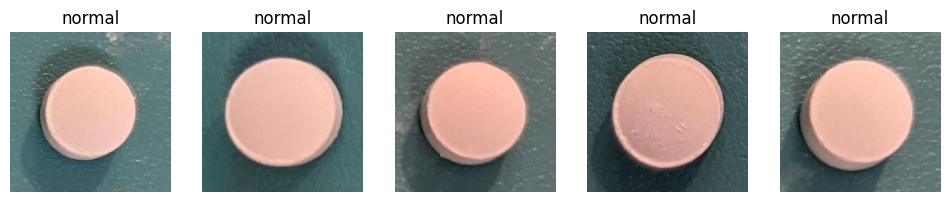

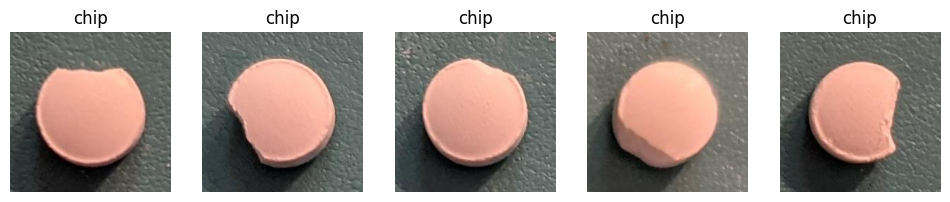

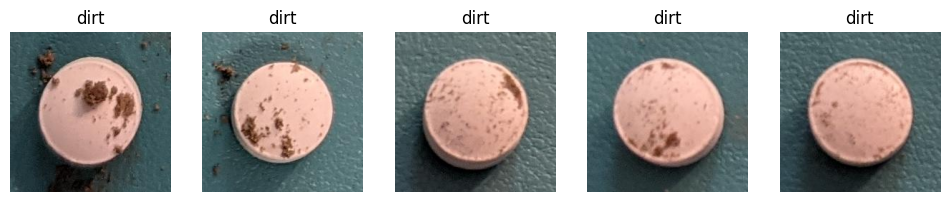

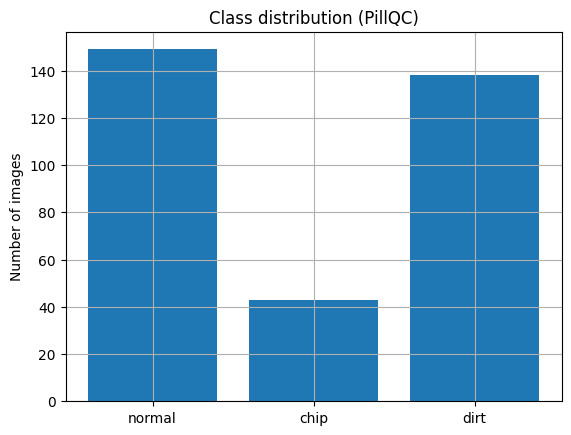

{'normal': 149, 'chip': 43, 'dirt': 138}


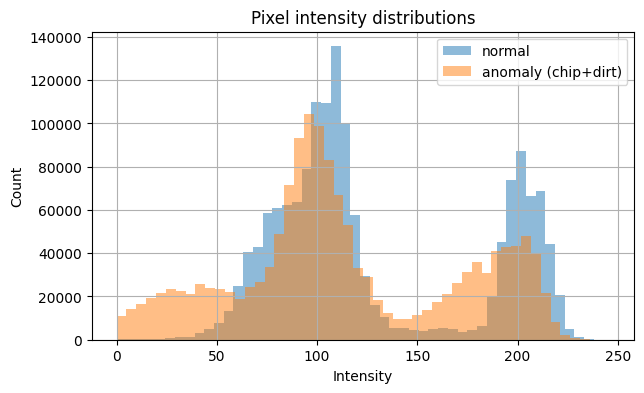

In [ ]:
# ----------------------------------------------------------------
# EDA
# ----------------------------------------------------------------
show_samples("normal", n=5)
show_samples("chip", n=5)
show_samples("dirt", n=5)

counts = {c: len(list((images_root/c).glob("*.jpg"))) for c in ["normal","chip","dirt"]}
plt.figure()
plt.bar(counts.keys(), counts.values())
plt.title("Class distribution (PillQC)")
plt.ylabel("Number of images")
plt.grid(True)
plt.show()
print(counts)

def collect_pixels(file_list, max_imgs=30):
    px = []
    for f in file_list[:max_imgs]:
        img = np.array(Image.open(f).convert("L"))
        px.extend(img.flatten())
    return np.array(px)

normal_files = sorted((images_root/"normal").glob("*.jpg"))
anom_files = sorted((images_root/"chip").glob("*.jpg")) + sorted((images_root/"dirt").glob("*.jpg"))

normal_px = collect_pixels([str(p) for p in normal_files])
anom_px   = collect_pixels([str(p) for p in anom_files])

plt.figure(figsize=(7,4))
plt.hist(normal_px, bins=50, alpha=0.5, label="normal")
plt.hist(anom_px, bins=50, alpha=0.5, label="anomaly (chip+dirt)")
plt.title("Pixel intensity distributions")
plt.xlabel("Intensity")
plt.ylabel("Count")
plt.legend()
plt.grid(True)
plt.show()


# 3. Train/Val/Test split construction (with constraints)

- Training uses **mostly normal** images
- Training uses at most **35 anomaly images (~20%)**
- `chip` and `dirt` are combined as anomaly label, but we keep subtype strings for analysis.

Splits are saved to `splits.json` for reproducibility.

## 3.1 Data Splits

In [ ]:
# ----------------------------------------------------------------
# Splits
# ----------------------------------------------------------------
def make_splits(seed=42, n_train_anom_max=35, val_normal=15, val_anom=43, test_normal=14, test_anom=103):
    rng = random.Random(seed)

    normal = sorted((images_root/"normal").glob("*.jpg"))
    chip   = sorted((images_root/"chip").glob("*.jpg"))
    dirt   = sorted((images_root/"dirt").glob("*.jpg"))
    anomaly = chip + dirt

    # Shuffles deterministically
    rng.shuffle(normal)
    rng.shuffle(anomaly)

    # fixed val/test sizes for reproducibility
    # total normals = 149. allocates val_normal + test_normal and remainder to train.
    assert len(normal) == 149, f"Expected 149 normals, got {len(normal)}"
    assert len(anomaly) == 181, f"Expected 181 anomalies, got {len(anomaly)}"

    val_norm = normal[:val_normal]
    test_norm = normal[val_normal:val_normal+test_normal]
    train_norm = normal[val_normal+test_normal:]

    # anomalies: kept small amount for train, rest split into val/test
    train_anom = anomaly[:n_train_anom_max]
    remaining = anomaly[n_train_anom_max:]

    # allocates to val/test
    val_anom_list = remaining[:val_anom]
    test_anom_list = remaining[val_anom:val_anom+test_anom]
    assert len(test_anom_list) == test_anom, "Check anomaly split sizes"

    splits = {
        "train": {"normal": [str(p) for p in train_norm], "anomaly": [str(p) for p in train_anom]},
        "val":   {"normal": [str(p) for p in val_norm],  "anomaly": [str(p) for p in val_anom_list]},
        "test":  {"normal": [str(p) for p in test_norm], "anomaly": [str(p) for p in test_anom_list]},
    }
    return splits

splits_path = DATA_DIR / "splits.json"
splits = make_splits(seed=SEED, n_train_anom_max=35)

with open(splits_path, "w") as f:
    json.dump(splits, f, indent=2)

print("Saved splits:", splits_path)
for part in ["train","val","test"]:
    print(part, "normal", len(splits[part]["normal"]), "anomaly", len(splits[part]["anomaly"]))

# Leakage checks
train_set = set(splits["train"]["normal"] + splits["train"]["anomaly"])
val_set   = set(splits["val"]["normal"] + splits["val"]["anomaly"])
test_set  = set(splits["test"]["normal"] + splits["test"]["anomaly"])
print("Train ∩ Val:", len(train_set & val_set))
print("Train ∩ Test:", len(train_set & test_set))
print("Val ∩ Test:", len(val_set & test_set))


Saved splits: /content/pillQC_data/splits.json
train normal 120 anomaly 35
val normal 15 anomaly 43
test normal 14 anomaly 103
Train ∩ Val: 0
Train ∩ Test: 0
Val ∩ Test: 0


## 3.2 Split sizes

In [ ]:
# ----------------------------------------------------------------
# Split sizes
# ----------------------------------------------------------------
print("TRAIN normal:", len(splits["train"]["normal"]))
print("TRAIN anomaly:", len(splits["train"]["anomaly"]))
print("VAL normal:", len(splits["val"]["normal"]))
print("VAL anomaly:", len(splits["val"]["anomaly"]))
print("TEST normal:", len(splits["test"]["normal"]))
print("TEST anomaly:", len(splits["test"]["anomaly"]))


TRAIN normal: 120
TRAIN anomaly: 35
VAL normal: 15
VAL anomaly: 43
TEST normal: 14
TEST anomaly: 103


## 3.3 Output directories

In [ ]:
# ----------------------------------------------------------------
# Outputs
# ----------------------------------------------------------------
OUT_DIR = DATA_DIR / "outputs"
FIG_DIR = OUT_DIR / "figs"
MET_DIR = OUT_DIR / "metrics"
FIG_DIR.mkdir(parents=True, exist_ok=True)
MET_DIR.mkdir(parents=True, exist_ok=True)

def savefig(name):
    plt.tight_layout()
    plt.savefig(FIG_DIR / name, dpi=200, bbox_inches="tight")


# 4. **Method 1: HOG + One-Class SVM**

Histogram of gradients + one-class support vector machine is the handcrafted feature approach. Includes parameter sensitivity and kernel collapse diagnostics

### **Method 1 Pipeline**
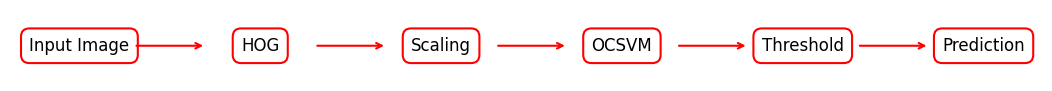

## 4.1 HOG feature extraction

In [ ]:
# ----------------------------------------------------------------
# HOG features
# ----------------------------------------------------------------
def hog_features(img01):
    # img01: float32 in [0,1]
    fd = hog(
        img01,
        orientations=9,#bins
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm="L2-Hys",
        visualize=False,
        feature_vector=True,
    )
    return fd.astype(np.float32)

def build_hog_matrix(paths, size=(128,128)):
    X = []
    for p in paths:
        img = load_gray(p, size=size)
        X.append(hog_features(img))
    return np.vstack(X)

# build matrices
X_train = build_hog_matrix(splits["train"]["normal"] + splits["train"]["anomaly"])
y_train = np.array([0]*len(splits["train"]["normal"]) + [1]*len(splits["train"]["anomaly"]))

X_val = build_hog_matrix(splits["val"]["normal"] + splits["val"]["anomaly"])
y_val = np.array([0]*len(splits["val"]["normal"]) + [1]*len(splits["val"]["anomaly"]))

X_test = build_hog_matrix(splits["test"]["normal"] + splits["test"]["anomaly"])
y_test = np.array([0]*len(splits["test"]["normal"]) + [1]*len(splits["test"]["anomaly"]))

scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

print("Shapes:", X_train_s.shape, X_val_s.shape, X_test_s.shape)


Shapes: (155, 8100) (58, 8100) (117, 8100)


HOG features were computed using 9 orientation bins, allowing gradient directions to be quantised into angular ranges. This enables the model to capture structural edge information, which is important for detecting defects such as chipped pill surfaces.

## 4.2 One-Class SVM parameter study + collapse detection

Anomalies are scored with `score = -decision_function`. Higher = more anomalous.

Several `nu` and `gamma` values are tested, and detect score collapse where std ≈ 0.

In [ ]:
# ----------------------------------------------------------------
# OCSVM parameters
# ----------------------------------------------------------------
from sklearn.metrics import precision_recall_curve

def eval_threshold_f1(y_true, scores):
    prec, rec, thr = precision_recall_curve(y_true, scores)
    f1s = 2*prec*rec/(prec+rec+1e-12)
    best_idx = int(np.nanargmax(f1s))
    best_f1 = float(f1s[best_idx])
    best_thr = float(thr[best_idx-1]) if best_idx > 0 and len(thr)>0 else float(np.nan)
    # compute precision/recall at best threshold
    y_pred = (scores >= best_thr).astype(int) if not np.isnan(best_thr) else np.zeros_like(y_true)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    p = tp/(tp+fp+1e-12); r = tp/(tp+fn+1e-12)
    return best_f1, best_thr, float(p), float(r), (tn,fp,fn,tp)

results = []
nus = [0.01, 0.05, 0.1]
gammas = ["scale", "auto", 0.0001, 0.001]

print("Val normal:", int((y_val==0).sum()))
print("Val anomaly:", int((y_val==1).sum()))

for nu in nus:
    for gamma in gammas:
        model = OneClassSVM(kernel="rbf", nu=nu, gamma=gamma)
        model.fit(X_train_s[y_train==0])  # fits on normal only for true anomaly detection framing

        val_scores = -model.decision_function(X_val_s)
        s_min, s_max, s_std = float(val_scores.min()), float(val_scores.max()), float(val_scores.std())
        collapsed = (s_std < 1e-6)

        roc = roc_auc_score(y_val, val_scores)
        pr  = average_precision_score(y_val, val_scores)

        best_f1, best_thr, p, r, (tn,fp,fn,tp) = eval_threshold_f1(y_val, val_scores)

        print(f"nu={nu:<4} gamma={str(gamma):<6} | s_min={s_min:.4f} s_max={s_max:.4f} s_std={s_std:.4f} | "
              f"ROC={roc:.4f} PR={pr:.4f} F1={best_f1:.4f} | P={p:.3f} R={r:.3f} | collapsed={collapsed}")

        results.append({
            "nu": nu, "gamma": gamma,
            "score_min": s_min, "score_max": s_max, "score_std": s_std, "collapsed": collapsed,
            "ROC_AUC": roc, "PR_AUC": pr, "Best_F1": best_f1, "Best_Thr": best_thr,
            "Precision_at_best": p, "Recall_at_best": r,
            "TN": tn, "FP": fp, "FN": fn, "TP": tp
        })

df_ocsvm = pd.DataFrame(results).sort_values(["Best_F1","PR_AUC","ROC_AUC"], ascending=False)
df_ocsvm.to_csv(MET_DIR/"ocsvm_param_study.csv", index=False)
df_ocsvm.head(10)


Val normal: 15
Val anomaly: 43
nu=0.01 gamma=scale  | s_min=-0.0159 s_max=0.1081 s_std=0.0331 | ROC=0.9752 PR=0.9902 F1=0.9773 | P=0.935 R=1.000 | collapsed=False
nu=0.01 gamma=auto   | s_min=-0.0185 s_max=0.1179 s_std=0.0362 | ROC=0.9752 PR=0.9902 F1=0.9773 | P=0.935 R=1.000 | collapsed=False
nu=0.01 gamma=0.0001 | s_min=-0.0255 s_max=0.1440 s_std=0.0446 | ROC=0.9736 PR=0.9897 F1=0.9773 | P=0.935 R=1.000 | collapsed=False
nu=0.01 gamma=0.001  | s_min=0.0100 s_max=0.0100 s_std=0.0000 | ROC=0.9783 PR=0.9921 F1=0.9773 | P=0.935 R=1.000 | collapsed=False
nu=0.05 gamma=scale  | s_min=-0.0800 s_max=0.5407 s_std=0.1654 | ROC=0.9752 PR=0.9902 F1=0.9773 | P=0.935 R=1.000 | collapsed=False
nu=0.05 gamma=auto   | s_min=-0.0922 s_max=0.5895 s_std=0.1811 | ROC=0.9752 PR=0.9902 F1=0.9773 | P=0.935 R=1.000 | collapsed=False
nu=0.05 gamma=0.0001 | s_min=-0.1271 s_max=0.7202 s_std=0.2231 | ROC=0.9736 PR=0.9897 F1=0.9773 | P=0.935 R=1.000 | collapsed=False
nu=0.05 gamma=0.001  | s_min=0.0500 s_max=0.05

,nu,gamma,score_min,score_max,score_std,collapsed,ROC_AUC,PR_AUC,Best_F1,Best_Thr,Precision_at_best,Recall_at_best,TN,FP,FN,TP
3,0.01,0.001,0.009994,0.010003,0.000002,False,0.978295,0.992103,0.977273,0.010003,0.934783,1.0,12,3,0,43
7,0.05,0.001,0.049968,0.050017,0.000010,False,0.978295,0.992103,0.977273,0.050014,0.934783,1.0,12,3,0,43
11,0.10,0.001,0.099935,0.100033,0.000020,False,0.978295,0.992103,0.977273,0.100027,0.934783,1.0,12,3,0,43
0,0.01,scale,-0.015943,0.108132,0.033063,False,0.975194,0.990194,0.977273,0.022397,0.934783,1.0,12,3,0,43
1,0.01,auto,-0.018470,0.117915,0.036219,False,0.975194,0.990194,0.977273,0.022008,0.934783,1.0,12,3,0,43
4,0.05,scale,-0.080018,0.540694,0.165359,False,0.975194,0.990194,0.977273,0.111949,0.934783,1.0,12,3,0,43
5,0.05,auto,-0.092160,0.589528,0.181098,False,0.975194,0.990194,0.977273,0.109737,0.934783,1.0,12,3,0,43
8,0.10,scale,-0.160014,1.081369,0.330707,False,0.975194,0.990194,0.977273,0.223785,0.934783,1.0,12,3,0,43
9,0.10,auto,-0.184282,1.179046,0.362185,False,0.975194,0.990194,0.977273,0.219488,0.934783,1.0,12,3,0,43
2,0.01,0.0001,-0.025451,0.144042,0.044626,False,0.973643,0.989666,0.977273,0.019843,0.934783,1.0,12,3,0,43


## 4.3 Fit best OCSVM and evaluate on TEST

Selecting the best config from `df_ocsvm` (highest validation F1).

In [ ]:
# ----------------------------------------------------------------
# Best OCSVM -> TEST evaluation
# ----------------------------------------------------------------
best_row = df_ocsvm.iloc[0]
best_nu = float(best_row["nu"])
best_gamma = best_row["gamma"]

ocsvm_best = OneClassSVM(kernel="rbf", nu=best_nu, gamma=best_gamma)
ocsvm_best.fit(X_train_s[y_train==0])

test_scores = -ocsvm_best.decision_function(X_test_s)

# threshold from VAL best_thr (validated)
best_thr_val = float(best_row["Best_Thr"])
y_pred_test = (test_scores >= best_thr_val).astype(int)

roc_test = roc_auc_score(y_test, test_scores)
pr_test  = average_precision_score(y_test, test_scores)
f1_test  = f1_score(y_test, y_pred_test)

cm = confusion_matrix(y_test, y_pred_test, labels=[0,1])
tn, fp, fn, tp = cm.ravel()

print("HOG+OCSVM TEST ROC:", roc_test)
print("HOG+OCSVM TEST PR :", pr_test)
print("HOG+OCSVM TEST F1 :", f1_test)
print("HOG+OCSVM CM [ [TN FP], [FN TP] ]:\n", cm)


HOG+OCSVM TEST ROC: 0.9812760055478502
HOG+OCSVM TEST PR : 0.9975009094939562
HOG+OCSVM TEST F1 : 0.9381443298969072
HOG+OCSVM CM [ [TN FP], [FN TP] ]:
 [[14  0]
 [12 91]]


The model achieves high specificity, indicating that normal samples are rarely misclassified. However, some anomalies are missed, suggesting sensitivity to subtle defect patterns.

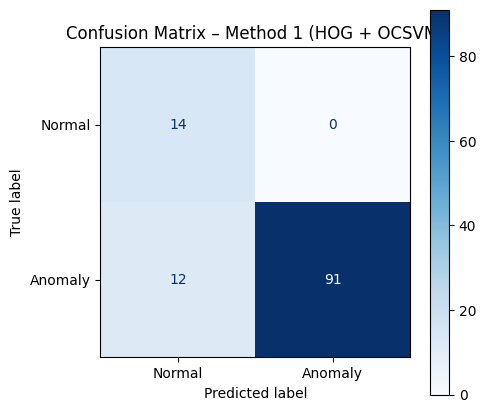

In [ ]:
# ------- Plot Confusion Matrix -------
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5,5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "Anomaly"]
)

disp.plot(ax=ax, cmap="Blues", values_format="d")
plt.title("Confusion Matrix – Method 1 (HOG + OCSVM)")
plt.show()

The HOG + OCSVM method achieved high specificity and strong overall sensitivity, suggesting that gradient-based handcrafted features are effective for detecting pill defects, particularly those with structural edge changes.

## 4.4 ROC + PR curves (Method 1)

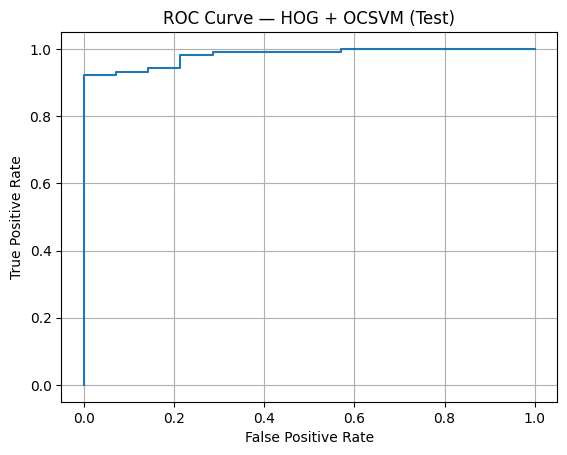

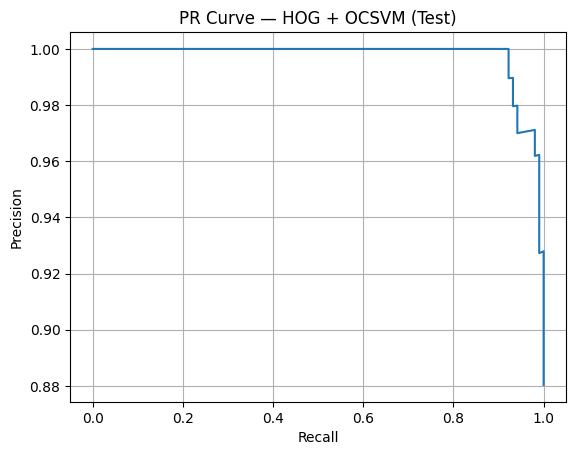

In [ ]:
# ----------------------------------------------------------------
# ROC curve
# ----------------------------------------------------------------
fpr, tpr, _ = roc_curve(y_test, test_scores)
plt.figure()
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — HOG + OCSVM (Test)")
plt.grid(True)
# savefig("roc_hog_test.png")
plt.show()

# PR curve
prec, rec, _ = precision_recall_curve(y_test, test_scores)
plt.figure()
plt.plot(rec, prec)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("PR Curve — HOG + OCSVM (Test)")
plt.grid(True)
# savefig("pr_hog_test.png")
plt.show()


## 4.5 Chip vs Dirt breakdown (Method 1)

In [ ]:
test_files_m1 = splits["test"]["normal"] + splits["test"]["anomaly"]

hog_subtypes = []
for p in test_files_m1:
    if "normal" in p: hog_subtypes.append("normal")
    elif "chip" in p: hog_subtypes.append("chip")
    else: hog_subtypes.append("dirt")
hog_subtypes = np.array(hog_subtypes)

pred_label = np.where(y_pred_test==1, "anomaly", "normal")
df_m1 = pd.DataFrame({"true": hog_subtypes, "pred": pred_label})
pd.crosstab(df_m1["true"], df_m1["pred"])


pred,anomaly,normal
true,,
chip,23,2
dirt,68,10
normal,0,14


## 4.6 HOG visualisation

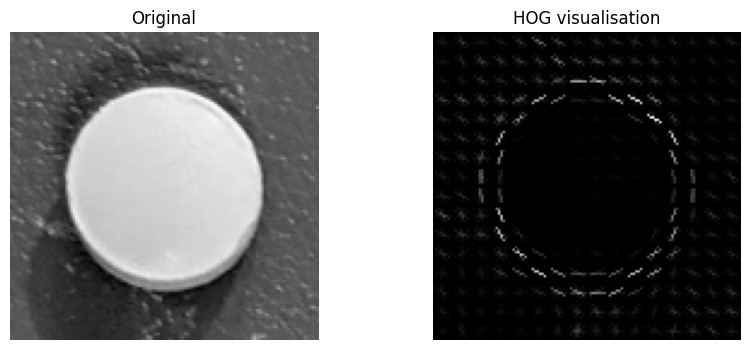

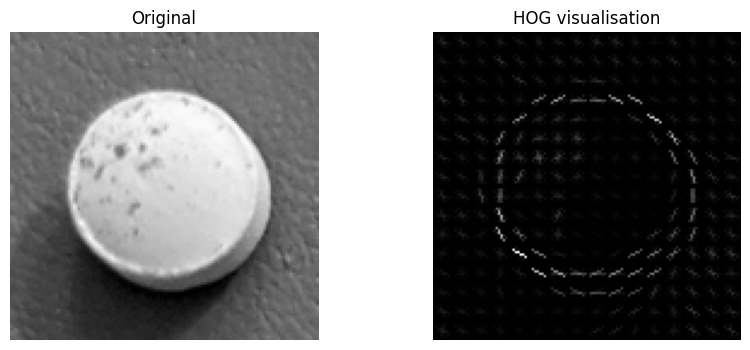

In [ ]:
def show_hog(path, size=(128,128)):
    img = load_gray(path, size=size)
    fd, hog_img = hog(
        img,
        orientations=9, # Bins
        pixels_per_cell=(8,8),
        cells_per_block=(2,2),
        block_norm="L2-Hys",
        visualize=True,
        feature_vector=True,
    )
    hog_vis = exposure.rescale_intensity(hog_img, in_range=(0,10))
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1); plt.imshow(img, cmap="gray"); plt.axis("off"); plt.title("Original")
    plt.subplot(1,2,2); plt.imshow(hog_vis, cmap="gray"); plt.axis("off"); plt.title("HOG visualisation")
    plt.show()

show_hog(splits["val"]["normal"][0])
show_hog(splits["val"]["anomaly"][0])


# 5. **Method 2: Convolutional Autoencoder** (PyTorch)
Deep Learning reconstruction-based anomaly detection.



### **Method 2 Pipeline**
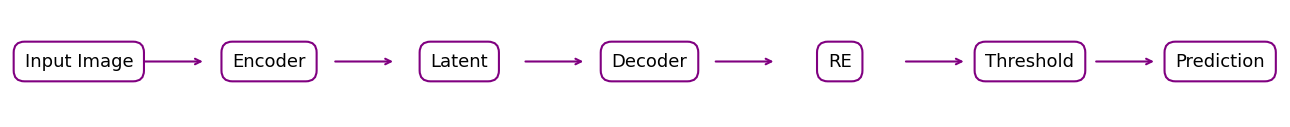

## 5.1 Data augmentation (train only)
Augmentation is applied only to **training normal** images to simulate minor variations (pose/lighting) without leaking augmentation into evaluation.


In [ ]:
import torchvision.transforms as T

train_tf = T.Compose([
    T.ToPILImage(),
    T.RandomAffine(degrees=8, translate=(0.02, 0.02), scale=(0.98, 1.02)),
    T.ColorJitter(brightness=0.1, contrast=0.1),
    T.ToTensor(),  # (1,H,W) float [0,1]
])

test_tf = T.Compose([
    T.ToPILImage(),
    T.ToTensor(),
])


## 5.2 AE Dataset + Loaders
Returns `(x, y, subtype, path)` where subtype ∈ {normal, chip, dirt}.

In [ ]:
class PillAEDataset(Dataset):
    def __init__(self, file_list, size=(128,128), transform=None):
        self.files = [str(p) for p in file_list]
        self.size = size
        self.transform = transform

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        path = self.files[idx]
        img = Image.open(path).convert("L").resize(self.size)
        arr = np.array(img, dtype=np.uint8)

        if self.transform is not None:
            x = self.transform(arr)  # tensor (1,H,W) float in [0,1]
        else:
            x = torch.tensor(arr, dtype=torch.float32).unsqueeze(0) / 255.0

        if "normal" in path:
            y, st = 0, "normal"
        elif "chip" in path:
            y, st = 1, "chip"
        else:
            y, st = 1, "dirt"

        return x, torch.tensor(y, dtype=torch.long), st, path

IMG_SIZE = (128,128)

train_files = splits["train"]["normal"]  # TRAIN AE ON NORMAL ONLY
val_files   = splits["val"]["normal"] + splits["val"]["anomaly"]
test_files  = splits["test"]["normal"] + splits["test"]["anomaly"]

train_ds = PillAEDataset(train_files, size=IMG_SIZE, transform=train_tf)
val_ds   = PillAEDataset(val_files,   size=IMG_SIZE, transform=None)
test_ds  = PillAEDataset(test_files,  size=IMG_SIZE, transform=None)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=0)

print("Train:", len(train_ds), "Val:", len(val_ds), "Test:", len(test_ds))

# sanity check
x, y, st, p = next(iter(train_loader))
print("Batch:", x.shape, "min/max:", float(x.min()), float(x.max()), "labels:", y[:5].tolist(), "subtypes:", st[:5])


Train: 120 Val: 58 Test: 117
Batch: torch.Size([32, 1, 128, 128]) min/max: 0.0 1.0 labels: [0, 0, 0, 0, 0] subtypes: ('normal', 'normal', 'normal', 'normal', 'normal')


## 5.3 Autoencoder model (latent dim configurable)

In [ ]:
class ConvAE(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()
        self.enc = nn.Sequential(
            nn.Conv2d(1, 16, 3, stride=2, padding=1),  # 16x64x64
            nn.ReLU(),
            nn.Conv2d(16, 32, 3, stride=2, padding=1), # 32x32x32
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1), # 64x16x16
            nn.ReLU(),
        )
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(64*16*16, latent_dim)

        self.fc2 = nn.Linear(latent_dim, 64*16*16)
        self.unflatten = nn.Unflatten(1, (64,16,16))
        self.dec = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 16, 3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, 3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        h = self.enc(x)
        h = self.flatten(h)
        z = self.fc1(h)
        h2 = self.fc2(z)
        h2 = self.unflatten(h2)
        xhat = self.dec(h2)
        return xhat


## 5.4 Training + scoring utilities

In [ ]:
def train_ae(latent_dim=128, epochs=25, lr=1e-3, patience=5):
    # Train autoencoder on (primarily) normal data
    # Early stopping based on validation loss computed on NORMAL samples only

    model = ConvAE(latent_dim=latent_dim).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    crit = nn.MSELoss()  # reconstruction loss

    best_val = float("inf")   # track best validation loss
    best_state = None         # store best model weights
    bad = 0                   # early stopping counter

    for ep in range(1, epochs+1):
        model.train()
        tr_losses = []

        # ----- Training loop -----
        for x, _, _, _ in train_loader:
            x = x.to(device)
            opt.zero_grad()
            xhat = model(x)           # forward pass
            loss = crit(xhat, x)      # reconstruction error
            loss.backward()
            opt.step()
            tr_losses.append(loss.item())

        # ----- Validation (NORMAL samples only) -----
        model.eval()
        val_losses = []
        with torch.no_grad():
            for x, y, _, _ in val_loader:
                x = x.to(device)
                y_np = y.numpy()

                # mask to select only normal samples (label = 0)
                mask = (y_np == 0)
                if mask.any():
                    x_n = x[torch.tensor(mask, device=device)]
                    xhat_n = model(x_n)
                    val_losses.append(crit(xhat_n, x_n).item())

        # mean losses
        tr = float(np.mean(tr_losses))
        va = float(np.mean(val_losses)) if len(val_losses) else tr

        print(f"latent={latent_dim} | epoch {ep:02d} | train={tr:.6f} | val(normal)={va:.6f}")

        # ----- Early stopping -----
        if va < best_val - 1e-6:
            best_val = va
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad = 0
        else:
            bad += 1
            if bad >= patience:
                print("Early stop.")
                break

    # load best model (based on validation)
    model.load_state_dict(best_state)
    return model


def recon_scores(model, loader):
    # Compute reconstruction error per image (used as anomaly score)

    model.eval()
    scores, ys, subs, paths = [], [], [], []

    with torch.no_grad():
        for x, y, st, p in loader:
            x = x.to(device)
            xhat = model(x)

            # mean squared reconstruction error per sample
            err = ((xhat - x)**2).mean(dim=(1,2,3)).detach().cpu().numpy()

            scores.extend(err.tolist())
            ys.extend(y.numpy().tolist())
            subs.extend(list(st))
            paths.extend(list(p))

    return np.array(scores), np.array(ys), np.array(subs), np.array(paths)


def threshold_from_train(train_scores_normal, percentile):
    # Select anomaly threshold based on percentile of normal training scores
    # Higher percentile → stricter anomaly detection

    return float(np.percentile(train_scores_normal, percentile))

## 5.5 Latent dimension mini-study + choosing best

Evaluation using percentile thresholds derived from train-normal reconstruction errors.

In [ ]:
latent_dims = [32, 64, 128]         # different AE capacities to evaluate
percentiles = [95.0, 97.5]          # threshold levels (strict anomaly cut-offs)

rows = []
models = {}

for ld in latent_dims:
    # Train AE for current latent dimension
    model = train_ae(latent_dim=ld, epochs=25, lr=1e-3, patience=5)
    models[ld] = model

    # Compute reconstruction scores
    train_scores, _, _, _ = recon_scores(
        model, DataLoader(train_ds, batch_size=32, shuffle=False)
    )
    val_scores, val_y, _, _ = recon_scores(model, val_loader)
    test_scores_ae, test_y_ae, _, _ = recon_scores(model, test_loader)

    # Evaluate different threshold percentiles
    for pct in percentiles:
        # threshold derived from NORMAL training scores
        thr = threshold_from_train(train_scores, pct)

        # classify anomalies based on reconstruction error
        y_pred = (test_scores_ae >= thr).astype(int)

        # confusion matrix + metrics
        tn, fp, fn, tp = confusion_matrix(test_y_ae, y_pred, labels=[0,1]).ravel()
        f1 = f1_score(test_y_ae, y_pred)

        rows.append({
            "latent_dim": ld,
            "threshold_pct": pct,
            "thr_value": thr,

            # validation performance (for model selection insight)
            "VAL_ROC": roc_auc_score(val_y, val_scores),
            "VAL_PR": average_precision_score(val_y, val_scores),

            # test performance (final evaluation)
            "TEST_ROC": roc_auc_score(test_y_ae, test_scores_ae),
            "TEST_PR": average_precision_score(test_y_ae, test_scores_ae),
            "TEST_F1": f1,

            # confusion matrix components
            "TEST_TN": tn,
            "TEST_FP": fp,
            "TEST_FN": fn,
            "TEST_TP": tp
        })

# rank configurations by test performance
df_study = pd.DataFrame(rows).sort_values(
    ["TEST_F1", "TEST_PR", "TEST_ROC"], ascending=False
)

# save results for reproducibility
df_study.to_csv(MET_DIR/"ae_latent_threshold_study.csv", index=False)

df_study

latent=32 | epoch 01 | train=0.053865 | val(normal)=0.044046
latent=32 | epoch 02 | train=0.053467 | val(normal)=0.040525
latent=32 | epoch 03 | train=0.045743 | val(normal)=0.031496
latent=32 | epoch 04 | train=0.034872 | val(normal)=0.021317
latent=32 | epoch 05 | train=0.026867 | val(normal)=0.016347
latent=32 | epoch 06 | train=0.021726 | val(normal)=0.012613
latent=32 | epoch 07 | train=0.018288 | val(normal)=0.011479
latent=32 | epoch 08 | train=0.015766 | val(normal)=0.009985
latent=32 | epoch 09 | train=0.015626 | val(normal)=0.010443
latent=32 | epoch 10 | train=0.013987 | val(normal)=0.008407
latent=32 | epoch 11 | train=0.012821 | val(normal)=0.008824
latent=32 | epoch 12 | train=0.012861 | val(normal)=0.008282
latent=32 | epoch 13 | train=0.012845 | val(normal)=0.008855
latent=32 | epoch 14 | train=0.012491 | val(normal)=0.008065
latent=32 | epoch 15 | train=0.012317 | val(normal)=0.008392
latent=32 | epoch 16 | train=0.012008 | val(normal)=0.008276
latent=32 | epoch 17 | t

,latent_dim,threshold_pct,thr_value,VAL_ROC,VAL_PR,TEST_ROC,TEST_PR,TEST_F1,TEST_TN,TEST_FP,TEST_FN,TEST_TP
2,64,95.0,0.013236,0.961240,0.986122,0.980583,0.997295,0.338710,14,0,82,21
3,64,97.5,0.014002,0.961240,0.986122,0.980583,0.997295,0.254237,14,0,88,15
4,128,95.0,0.012358,0.982946,0.993887,0.964632,0.994662,0.224138,14,0,90,13
0,32,95.0,0.016586,0.869767,0.948912,0.904300,0.982902,0.176991,14,0,93,10
5,128,97.5,0.013704,0.982946,0.993887,0.964632,0.994662,0.144144,14,0,95,8
1,32,97.5,0.017732,0.869767,0.948912,0.904300,0.982902,0.127273,14,0,96,7


## 5.6 Choosing best AE model and calibrate threshold
Latent=128 and percentile sweep (90–95) to trade off FN vs FP.


In [ ]:
# ----------------------------------------------------------------
# Choosing best AE model and calibrate threshold (VAL-based, FP-budgeted)
# ----------------------------------------------------------------

# Latent selection (no test leakage)
best_row = df_study.sort_values(["VAL_PR", "VAL_ROC"], ascending=False).iloc[0]
BEST_LATENT = int(best_row["latent_dim"])
best_model = models[BEST_LATENT]
print("Chosen latent (by VAL_PR then VAL_ROC):", BEST_LATENT)

# Scores
train_scores, _, _, _ = recon_scores(
    best_model,
    DataLoader(train_ds, batch_size=32, shuffle=False, num_workers=0)
)
val_scores_ae, val_y_ae, val_st_ae, val_paths_ae = recon_scores(best_model, val_loader)
test_scores_ae, test_y_ae, test_st_ae, test_paths_ae = recon_scores(best_model, test_loader)

print("VAL normals/anoms:", int((val_y_ae==0).sum()), int((val_y_ae==1).sum()))
print("TEST normals/anoms:", int((test_y_ae==0).sum()), int((test_y_ae==1).sum()))

# FP-budgeted threshold sweep on VAL
percentile_sweep = list(range(50, 100))  # wider range
rows = []

for pct in percentile_sweep:
    thr = threshold_from_train(train_scores, pct)

    val_pred = (val_scores_ae >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(val_y_ae, val_pred, labels=[0,1]).ravel()

    tpr = tp / (tp + fn + 1e-12)
    tnr = tn / (tn + fp + 1e-12)
    bal_acc = 0.5 * (tpr + tnr)
    f1 = f1_score(val_y_ae, val_pred)

    rows.append({
        "percentile": pct,
        "threshold": thr,
        "VAL_TPR": tpr, "VAL_TNR": tnr,
        "VAL_BalAcc": bal_acc, "VAL_F1": f1,
        "VAL_TN": tn, "VAL_FP": fp, "VAL_FN": fn, "VAL_TP": tp
    })

df_sweep = pd.DataFrame(rows)

# Allow a small number of FP on VAL to reduce FN dramatically
FP_BUDGET = 2  # try 2 first; you can set 1 or 3
df_ok = df_sweep[df_sweep["VAL_FP"] <= FP_BUDGET].copy()

# Primary objective: maximise TPR (catch anomalies). Tie-breaker: maximise BalAcc, then F1
df_ok = df_ok.sort_values(["VAL_TPR", "VAL_BalAcc", "VAL_F1"], ascending=False).reset_index(drop=True)

print("Top 10 thresholds under FP budget (VAL):")
print(df_ok.head(10))

df_sweep_ok = df_ok  # keep for next cell


Chosen latent (by VAL_PR then VAL_ROC): 128
VAL normals/anoms: 15 43
TEST normals/anoms: 14 103
Top 10 thresholds under FP budget (VAL):
   percentile  threshold   VAL_TPR  VAL_TNR  VAL_BalAcc    VAL_F1  VAL_TN  \
0          50   0.007948  0.790698      1.0    0.895349  0.883117      15   
1          51   0.008014  0.790698      1.0    0.895349  0.883117      15   
2          52   0.008031  0.790698      1.0    0.895349  0.883117      15   
3          53   0.008041  0.790698      1.0    0.895349  0.883117      15   
4          54   0.008157  0.790698      1.0    0.895349  0.883117      15   
5          55   0.008160  0.790698      1.0    0.895349  0.883117      15   
6          56   0.008281  0.744186      1.0    0.872093  0.853333      15   
7          57   0.008367  0.744186      1.0    0.872093  0.853333      15   
8          58   0.008386  0.744186      1.0    0.872093  0.853333      15   
9          59   0.008401  0.744186      1.0    0.872093  0.853333      15   

   VAL_FP  VAL_

## 5.7 Lock best threshold (usually percentile=90)
Final **confusion matrix** and chip/dirt breakdown for the chosen operating point.

In [ ]:
# ----------------------------------------------------------------
# Lock best threshold from FP-budgeted VAL sweep and evaluate TEST once
# ----------------------------------------------------------------

BEST_PCT = int(df_sweep_ok.iloc[0]["percentile"])
best_thr = float(df_sweep_ok.iloc[0]["threshold"])

print("Selected threshold from VAL:", best_thr, "| percentile:", BEST_PCT)

y_pred_ae = (test_scores_ae >= best_thr).astype(int)
cm_ae = confusion_matrix(test_y_ae, y_pred_ae, labels=[0, 1])
tn, fp, fn, tp = cm_ae.ravel()

roc_ae = roc_auc_score(test_y_ae, test_scores_ae)
pr_ae  = average_precision_score(test_y_ae, test_scores_ae)
f1_ae  = f1_score(test_y_ae, y_pred_ae)

print(f"\nAE FINAL TEST (latent={BEST_LATENT}, pct={BEST_PCT})")
print(f"ROC={roc_ae:.4f} | PR={pr_ae:.4f} | F1={f1_ae:.4f}")
print("AE Confusion Matrix [[TN FP],[FN TP]]:\n", cm_ae)
print("TN, FP, FN, TP:", tn, fp, fn, tp)

df_ae = pd.DataFrame({
    "true": test_st_ae,
    "pred": np.where(y_pred_ae == 1, "anomaly", "normal")
})
print("\nChip vs Dirt breakdown:")
print(pd.crosstab(df_ae["true"], df_ae["pred"]))




Selected threshold from VAL: 0.007947867270559072 | percentile: 50

AE FINAL TEST (latent=128, pct=50)
ROC=0.9646 | PR=0.9947 | F1=0.8182
AE Confusion Matrix [[TN FP],[FN TP]]:
 [[13  1]
 [31 72]]
TN, FP, FN, TP: 13 1 31 72

Chip vs Dirt breakdown:
pred    anomaly  normal
true                   
chip         25       0
dirt         47      31
normal        1      13


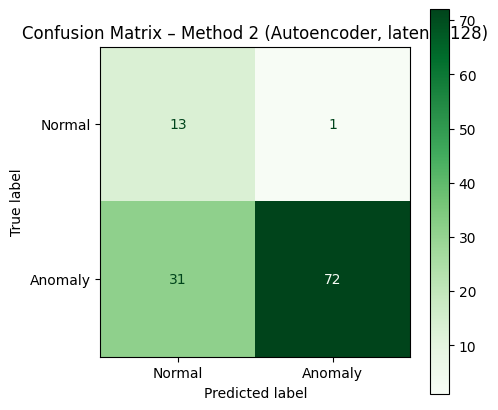

In [ ]:
# ------- Plot Confusion Matrix -------
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5,5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_ae,
    display_labels=["Normal", "Anomaly"]
)

disp.plot(ax=ax, cmap="Greens", values_format="d")
plt.title(f"Confusion Matrix – Method 2 (Autoencoder, latent={BEST_LATENT})")
plt.show()

The autoencoder achieved strong chip detection but lower dirt detection performance, indicating that reconstruction-based approaches may smooth subtle contamination patterns and therefore under-detect texture-like anomalies.

## 5.8 AE Interpretability: reconstruction heatmaps
Shows `original`, `reconstruction`, and `|diff|` (error map).

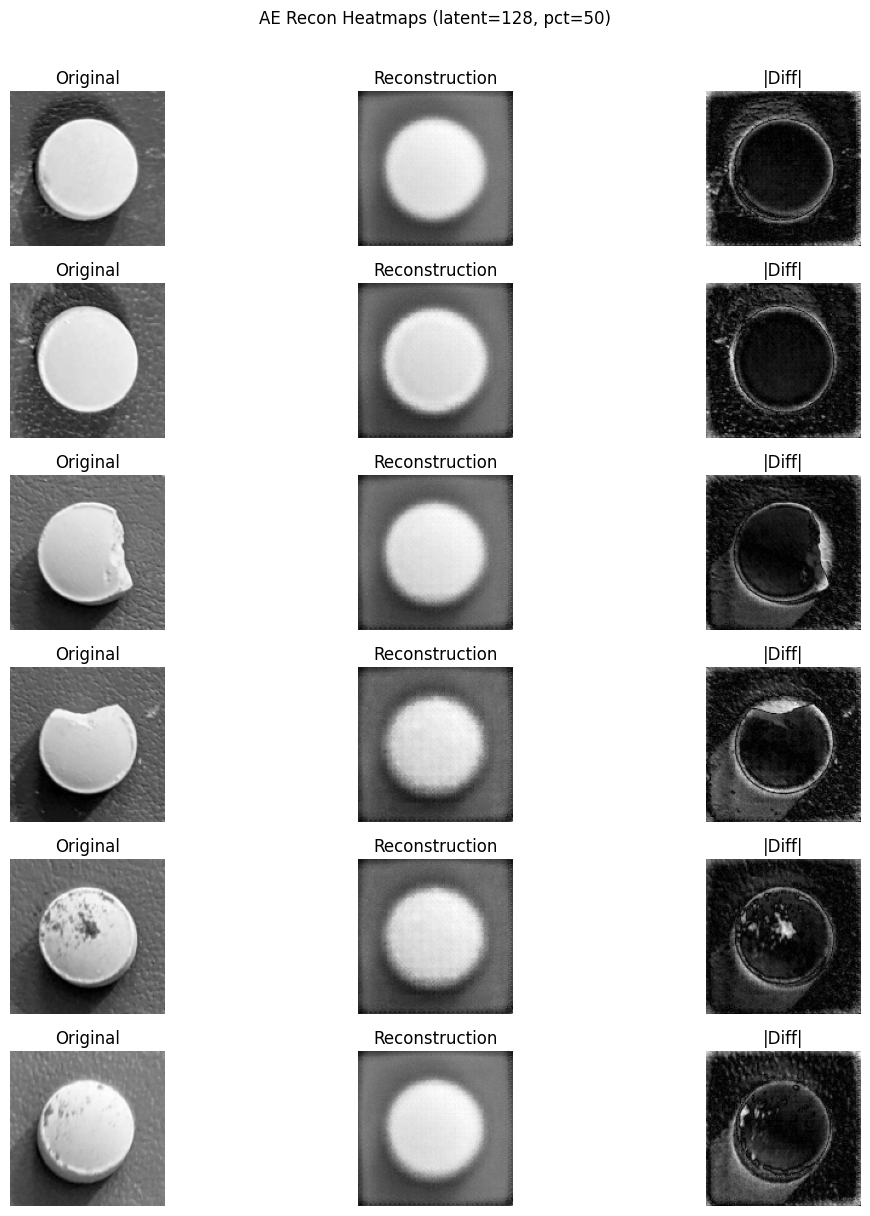

In [ ]:
def show_recon_examples(model, file_paths, n=6, title="AE Recon Heatmaps"):
    # Visualise original image, reconstruction, and absolute difference (error heatmap)

    model.eval()
    file_paths = [str(p) for p in file_paths]
    picks = file_paths[:n]  # select subset of images

    plt.figure(figsize=(12, 2*n))

    for i, p in enumerate(picks):
        # load and normalise image
        img = Image.open(p).convert("L").resize(IMG_SIZE)
        x = np.array(img, dtype=np.float32) / 255.0
        xt = torch.tensor(x).unsqueeze(0).unsqueeze(0).to(device)

        # reconstruct using trained autoencoder
        with torch.no_grad():
            xhat = model(xt).detach().cpu().numpy().squeeze()

        # absolute reconstruction error (anomaly signal)
        diff = np.abs(xhat - x)

        # plot: original | reconstruction | error heatmap
        plt.subplot(n, 3, 3*i+1); plt.imshow(x, cmap="gray"); plt.axis("off"); plt.title("Original")
        plt.subplot(n, 3, 3*i+2); plt.imshow(xhat, cmap="gray"); plt.axis("off"); plt.title("Reconstruction")
        plt.subplot(n, 3, 3*i+3); plt.imshow(diff, cmap="gray"); plt.axis("off"); plt.title("|Diff|")

    plt.suptitle(title, y=1.01)
    plt.tight_layout()
    plt.show()


# Select examples from each class for comparison
test_normals = [p for p in test_files if "normal" in p]
test_chips   = [p for p in test_files if "chip" in p]
test_dirts   = [p for p in test_files if "dirt" in p]

# mix of normal, chip, and dirt samples
examples = test_normals[:2] + test_chips[:2] + test_dirts[:2]

show_recon_examples(
    best_model,
    examples,
    n=6,
    title=f"AE Recon Heatmaps (latent={BEST_LATENT}, pct={BEST_PCT})"
)


## 5.9 Distribution Plot of Reconstruction Errors

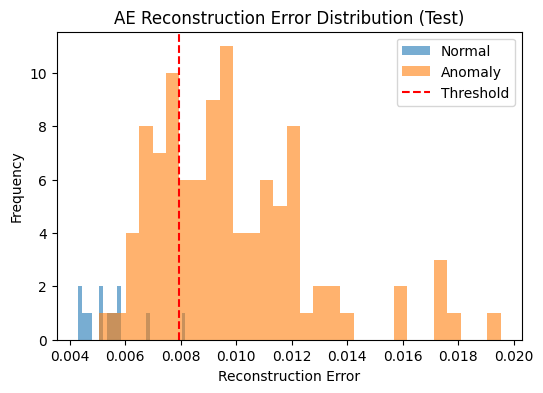

In [ ]:
# ------- Plot Distribution Error -------
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(test_scores_ae[test_y_ae==0], bins=30, alpha=0.6, label="Normal")
plt.hist(test_scores_ae[test_y_ae==1], bins=30, alpha=0.6, label="Anomaly")
plt.axvline(best_thr, color="red", linestyle="--", label="Threshold")
plt.title("AE Reconstruction Error Distribution (Test)")
plt.xlabel("Reconstruction Error")
plt.ylabel("Frequency")
plt.legend()
plt.show()


# 6. Score distributions (Method 1 vs Method 2)

## 6.1 Feature space visualisation (t-SNE)

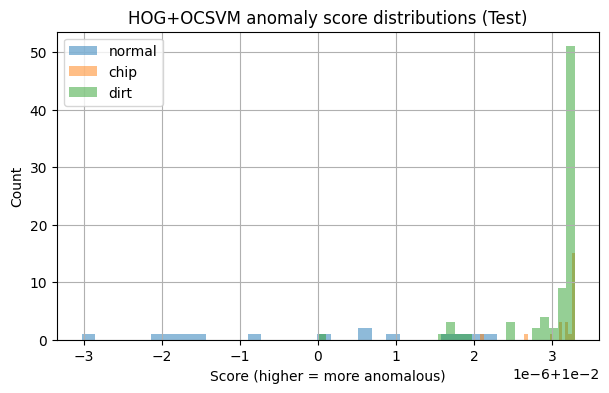

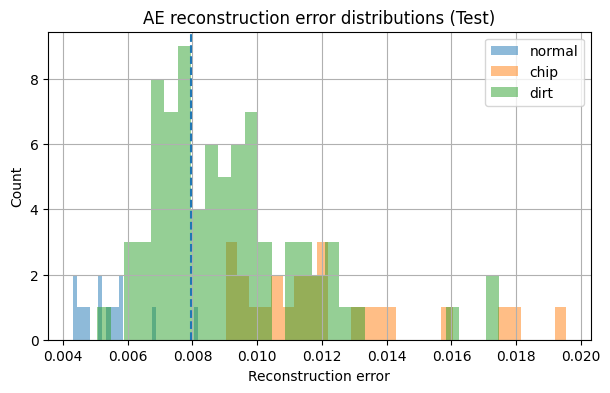

In [ ]:
# ----------------------------------------------------------------
# Score distributions
# ----------------------------------------------------------------
plt.figure(figsize=(7,4))
for name in ["normal","chip","dirt"]:
    m = (hog_subtypes == name)
    plt.hist(test_scores[m], bins=30, alpha=0.5, label=name)
plt.title("HOG+OCSVM anomaly score distributions (Test)")
plt.xlabel("Score (higher = more anomalous)")
plt.ylabel("Count")
plt.legend(); plt.grid(True)
plt.show()

plt.figure(figsize=(7,4))
for name in ["normal","chip","dirt"]:
    m = (test_st_ae == name)
    plt.hist(test_scores_ae[m], bins=30, alpha=0.5, label=name)
plt.axvline(best_thr, linestyle="--")
plt.title("AE reconstruction error distributions (Test)")
plt.xlabel("Reconstruction error")
plt.ylabel("Count")
plt.legend(); plt.grid(True)
plt.show()


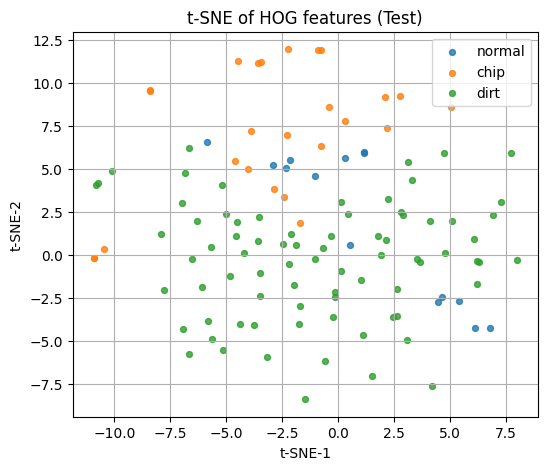

In [ ]:
# ----------------------------------------------------------------
# t-SNE — HOG feature space (TEST)
# ----------------------------------------------------------------
X_hog_test = X_test_s
sub = hog_subtypes

X_pca = PCA(n_components=min(50, X_hog_test.shape[1]), random_state=SEED).fit_transform(X_hog_test)
Z = TSNE(n_components=2, perplexity=20, init="pca", learning_rate="auto", random_state=SEED).fit_transform(X_pca)

plt.figure(figsize=(6,5))
for name in ["normal","chip","dirt"]:
    m = (sub == name)
    plt.scatter(Z[m,0], Z[m,1], s=18, alpha=0.8, label=name)
plt.title("t-SNE of HOG features (Test)")
plt.xlabel("t-SNE-1"); plt.ylabel("t-SNE-2")
plt.legend(); plt.grid(True)
plt.show()


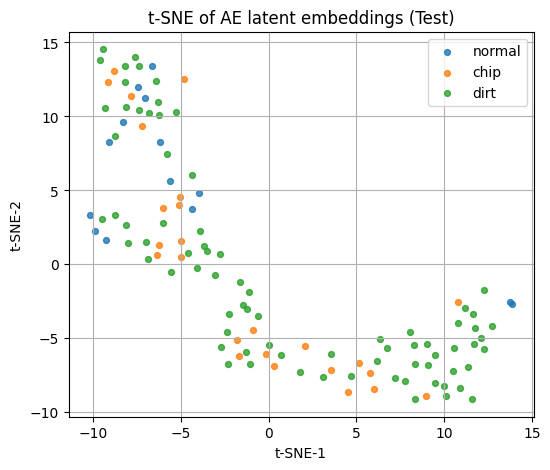

In [ ]:
# ----------------------------------------------------------------
# t-SNE — AE latent space (TEST)
# ----------------------------------------------------------------
def extract_latents(model, loader):
    model.eval()
    Zs, subs = [], []
    with torch.no_grad():
        for x, y, st, p in loader:
            x = x.to(device)
            h = model.enc(x)
            h = model.flatten(h)
            z = model.fc1(h)
            Zs.append(z.detach().cpu().numpy())
            subs.extend(list(st))
    return np.vstack(Zs), np.array(subs)

Z_lat, subs_lat = extract_latents(best_model, test_loader)
Zp = PCA(n_components=min(50, Z_lat.shape[1]), random_state=SEED).fit_transform(Z_lat)
Z2 = TSNE(n_components=2, perplexity=20, init="pca", learning_rate="auto", random_state=SEED).fit_transform(Zp)

plt.figure(figsize=(6,5))
for name in ["normal","chip","dirt"]:
    m = (subs_lat == name)
    plt.scatter(Z2[m,0], Z2[m,1], s=18, alpha=0.8, label=name)
plt.title("t-SNE of AE latent embeddings (Test)")
plt.xlabel("t-SNE-1"); plt.ylabel("t-SNE-2")
plt.legend(); plt.grid(True)
plt.show()


## 6.2 Failure Case Analysis

This section visualises examples of false negatives and false positives for both methods. The aim is to understand which types of anomalies are more difficult to detect and why.

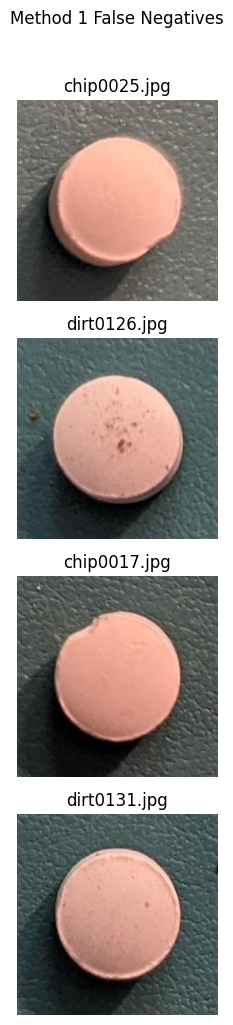

No cases found for: Method 1 False Positives


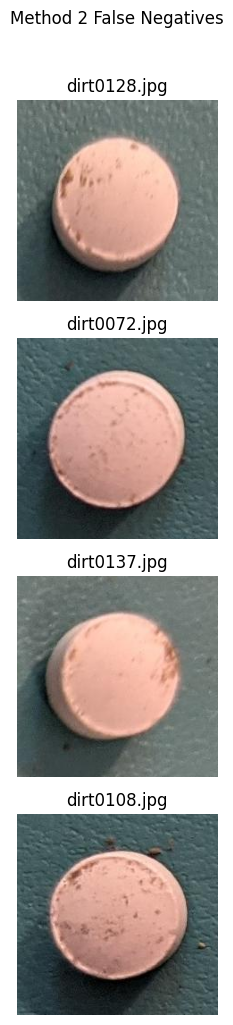

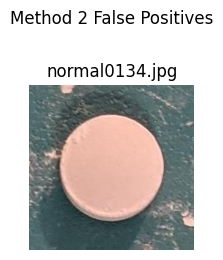

In [ ]:
# ----------------------------------------------------------------
# Failure case gallery
# ----------------------------------------------------------------
import matplotlib.pyplot as plt
from PIL import Image

def show_failure_cases(file_paths, title, n=6):
    file_paths = list(file_paths)[:n]
    if len(file_paths) == 0:
        print(f"No cases found for: {title}")
        return

    plt.figure(figsize=(12, 2.5 * len(file_paths)))
    for i, p in enumerate(file_paths):
        img = Image.open(p)
        plt.subplot(len(file_paths), 1, i+1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(str(p).split("/")[-1])
    plt.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.show()

# ---------- Method 1 false negatives / false positives ----------
m1_false_negatives = [p for p, y_true, y_pred in zip(test_files_m1, y_test, y_pred_test) if y_true == 1 and y_pred == 0]
m1_false_positives = [p for p, y_true, y_pred in zip(test_files_m1, y_test, y_pred_test) if y_true == 0 and y_pred == 1]

# ---------- Method 2 false negatives / false positives ----------
m2_false_negatives = [p for p, y_true, y_pred in zip(test_paths_ae, test_y_ae, y_pred_ae) if y_true == 1 and y_pred == 0]
m2_false_positives = [p for p, y_true, y_pred in zip(test_paths_ae, test_y_ae, y_pred_ae) if y_true == 0 and y_pred == 1]

show_failure_cases(m1_false_negatives, "Method 1 False Negatives", n=4)
show_failure_cases(m1_false_positives, "Method 1 False Positives", n=4)

show_failure_cases(m2_false_negatives, "Method 2 False Negatives", n=4)
show_failure_cases(m2_false_positives, "Method 2 False Positives", n=4)

# 7. **Comparative Evaluation**

This section compares both methods using performance metrics and defect-type behaviour.

Key evaluation focuses:
- Sensitivity vs specificity trade-off
- Performance on chip vs dirt anomalies
- Model behaviour differences

## 7.1 Comparative summary (final table)


In [ ]:
# ----------------------------------------------------------------
# Comparative summary (final table) — SAFE (no variable collisions)
# ----------------------------------------------------------------

# ---- Method 1 (HOG + OCSVM) ----
m1_scores = test_scores
m1_ytrue  = y_test
m1_ypred  = y_pred_test

m1_cm = confusion_matrix(m1_ytrue, m1_ypred, labels=[0,1])
m1_tn, m1_fp, m1_fn, m1_tp = m1_cm.ravel()

m1 = {
    "Method": "HOG + One-Class SVM (HOG features)",
    "ROC_AUC": float(roc_auc_score(m1_ytrue, m1_scores)),
    "PR_AUC":  float(average_precision_score(m1_ytrue, m1_scores)),
    "F1":      float(f1_score(m1_ytrue, m1_ypred)),
    "TN": int(m1_tn), "FP": int(m1_fp), "FN": int(m1_fn), "TP": int(m1_tp),
}

# ---- Method 2 (AE) ----
m2_scores = test_scores_ae
m2_ytrue  = test_y_ae
m2_ypred  = y_pred_ae

m2_cm = confusion_matrix(m2_ytrue, m2_ypred, labels=[0,1])
m2_tn, m2_fp, m2_fn, m2_tp = m2_cm.ravel()

m2 = {
    "Method": f"Conv Autoencoder (latent={BEST_LATENT}, pct={BEST_PCT})",
    "ROC_AUC": float(roc_auc_score(m2_ytrue, m2_scores)),
    "PR_AUC":  float(average_precision_score(m2_ytrue, m2_scores)),
    "F1":      float(f1_score(m2_ytrue, m2_ypred)),
    "TN": int(m2_tn), "FP": int(m2_fp), "FN": int(m2_fn), "TP": int(m2_tp),
}

df_compare = pd.DataFrame([m1, m2])
df_compare


,Method,ROC_AUC,PR_AUC,F1,TN,FP,FN,TP
0,HOG + One-Class SVM (HOG features),0.981276,0.997501,0.938144,14,0,12,91
1,"Conv Autoencoder (latent=128, pct=50)",0.964632,0.994662,0.818182,13,1,31,72


## 7.2 Sensitivity & Specificity comparison (TEST)

In [ ]:
# ----------------------------------------------------------------
# Sensitivity & Specificity comparison (TEST)
# ----------------------------------------------------------------

from sklearn.metrics import confusion_matrix

def sensitivity_specificity(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    sensitivity = tp / (tp + fn + 1e-12)  # Recall
    specificity = tn / (tn + fp + 1e-12)
    return sensitivity, specificity

# Method 1
m1_sens, m1_spec = sensitivity_specificity(m1_ytrue, m1_ypred)

# Method 2
m2_sens, m2_spec = sensitivity_specificity(m2_ytrue, m2_ypred)

print("Method 1 (HOG + OCSVM)")
print("  Sensitivity:", round(m1_sens,4))
print("  Specificity:", round(m1_spec,4))

print("\nMethod 2 (Autoencoder)")
print("  Sensitivity:", round(m2_sens,4))
print("  Specificity:", round(m2_spec,4))


Method 1 (HOG + OCSVM)
  Sensitivity: 0.8835
  Specificity: 1.0

Method 2 (Autoencoder)
  Sensitivity: 0.699
  Specificity: 0.9286


## 7.3 Defect-Type Performance Comparison

This section compares the behaviour of both methods separately on chip and dirt defects, rather than treating all anomalies as a single group. This helps identify whether the methods respond differently to structural defects and contamination defects.

        Method  Chip Recall  Dirt Recall
0  HOG + OCSVM         0.92     0.871795
1  Autoencoder         1.00     0.602564


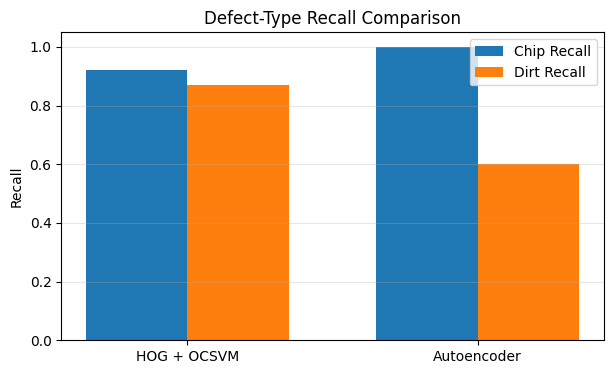

In [ ]:
# ----------------------------------------------------------------
# Defect-type recall comparison
# ----------------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Rebuild Method 1 test file list directly from splits
test_files_m1 = splits["test"]["normal"] + splits["test"]["anomaly"]

# ---------- Method 1 subtype recalls ----------
m1_subtypes = []
for p in test_files_m1:
    if "chip" in p:
        m1_subtypes.append("chip")
    elif "dirt" in p:
        m1_subtypes.append("dirt")
    else:
        m1_subtypes.append("normal")
m1_subtypes = np.array(m1_subtypes)

m1_chip_mask = (m1_subtypes == "chip")
m1_dirt_mask = (m1_subtypes == "dirt")

m1_chip_recall = (y_pred_test[m1_chip_mask] == 1).mean()
m1_dirt_recall = (y_pred_test[m1_dirt_mask] == 1).mean()

# ---------- Method 2 subtype recalls ----------
m2_chip_mask = (test_st_ae == "chip")
m2_dirt_mask = (test_st_ae == "dirt")

m2_chip_recall = (y_pred_ae[m2_chip_mask] == 1).mean()
m2_dirt_recall = (y_pred_ae[m2_dirt_mask] == 1).mean()

df_defect_compare = pd.DataFrame({
    "Method": ["HOG + OCSVM", "Autoencoder"],
    "Chip Recall": [m1_chip_recall, m2_chip_recall],
    "Dirt Recall": [m1_dirt_recall, m2_dirt_recall]
})

print(df_defect_compare)

# Plot
x = np.arange(len(df_defect_compare))
width = 0.35

plt.figure(figsize=(7,4))
plt.bar(x - width/2, df_defect_compare["Chip Recall"], width, label="Chip Recall")
plt.bar(x + width/2, df_defect_compare["Dirt Recall"], width, label="Dirt Recall")

plt.xticks(x, df_defect_compare["Method"])
plt.ylim(0, 1.05)
plt.ylabel("Recall")
plt.title("Defect-Type Recall Comparison")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.show()

The defect-type analysis shows that anomaly type matters. Structural defects are easier to detect than contamination defects, and the relative performance of each method depends on the visual characteristics of the anomaly.

## 7.4 Computational Benchmark

This section benchmarks the computational characteristics of both methods using the final trained models. The aim is to compare practical inference cost in addition to detection performance.

In [ ]:
# ----------------------------------------------------------------
# Computational benchmark
# ----------------------------------------------------------------
import time
import numpy as np
import pandas as pd
import torch

# -------------------------
# Helper: benchmark Method 1
# -------------------------
def benchmark_hog_ocsvm(file_paths, repeats=3):
    feature_times = []
    score_times = []
    total_times = []

    for _ in range(repeats):
        start_total = time.perf_counter()

        # HOG feature extraction
        start_feat = time.perf_counter()
        X = build_hog_matrix(file_paths)
        Xs = scaler.transform(X)
        end_feat = time.perf_counter()

        # OCSVM scoring
        start_score = time.perf_counter()
        _ = -ocsvm_best.decision_function(Xs)
        end_score = time.perf_counter()

        end_total = time.perf_counter()

        feature_times.append(end_feat - start_feat)
        score_times.append(end_score - start_score)
        total_times.append(end_total - start_total)

    n = len(file_paths)
    return {
        "Method": "HOG + OCSVM",
        "Images Benchmarked": n,
        "Avg Feature Extraction Time (s)": np.mean(feature_times),
        "Avg Scoring Time (s)": np.mean(score_times),
        "Avg Total Time (s)": np.mean(total_times),
        "Avg Time Per Image (ms)": (np.mean(total_times) / n) * 1000,
        "Feature Dimension": X.shape[1]
    }

# -------------------------
# Helper: benchmark Method 2
# -------------------------
def benchmark_autoencoder(loader, repeats=3):
    forward_times = []
    total_times = []

    best_model.eval()

    # preload batch tensors once for fairness
    batches = []
    for x, _, _, _ in loader:
        batches.append(x.to(device))

    with torch.no_grad():
        for _ in range(repeats):
            start_total = time.perf_counter()

            start_forward = time.perf_counter()
            for x in batches:
                xhat = best_model(x)
                _ = ((xhat - x) ** 2).mean(dim=(1,2,3))
            end_forward = time.perf_counter()

            end_total = time.perf_counter()

            forward_times.append(end_forward - start_forward)
            total_times.append(end_total - start_total)

    n = sum(batch.shape[0] for batch in batches)
    ae_params = sum(p.numel() for p in best_model.parameters())

    return {
        "Method": "Autoencoder",
        "Images Benchmarked": n,
        "Avg Forward Time (s)": np.mean(forward_times),
        "Avg Total Time (s)": np.mean(total_times),
        "Avg Time Per Image (ms)": (np.mean(total_times) / n) * 1000,
        "Trainable Parameters": ae_params
    }

# -------------------------
# Select benchmark dataset
# -------------------------
bench_paths = splits["test"]["normal"] + splits["test"]["anomaly"]

# for AE use the existing test loader
hog_bench = benchmark_hog_ocsvm(bench_paths, repeats=3)
ae_bench  = benchmark_autoencoder(test_loader, repeats=3)

df_benchmark = pd.DataFrame([hog_bench, ae_bench])
df_benchmark

,Method,Images Benchmarked,Avg Feature Extraction Time (s),Avg Scoring Time (s),Avg Total Time (s),Avg Time Per Image (ms),Feature Dimension,Avg Forward Time (s),Trainable Parameters
0,HOG + OCSVM,117,0.858593,0.100012,0.958608,8.193231,8100.0,NaN,NaN
1,Autoencoder,117,NaN,NaN,0.004184,0.035762,NaN,0.004183,4257345.0


The benchmark highlights key differences in computational behaviour between the two methods. The HOG + OCSVM pipeline requires explicit feature extraction prior to classification, which introduces additional preprocessing cost. In contrast, the autoencoder performs end-to-end inference through a forward pass, but involves a larger number of trainable parameters.

This reflects a trade-off between interpretability and computational complexity, where handcrafted feature methods are simpler and more transparent, while deep learning approaches are more flexible but computationally heavier.
Additionally, the per-image inference time suggests that both approaches are viable for small-scale deployment, although scalability may favour simpler feature-based methods.

# 8. Additional Analysis

## 8.1 Bootstrap confidence intervals (uncertainty)

In [ ]:
# ------- Bootstrap confidence intervals -------
def bootstrap_ci(y, scores, metric_fn, n=1000, seed=42):
    # Estimate mean and 95% confidence interval using bootstrap resampling

    rng = np.random.default_rng(seed)
    idx = np.arange(len(y))
    vals = []

    for _ in range(n):
        # sample with replacement
        sample = rng.choice(idx, size=len(idx), replace=True)
        vals.append(metric_fn(y[sample], scores[sample]))

    vals = np.sort(vals)

    # return mean and 95% CI bounds
    return float(np.mean(vals)), float(vals[int(0.025*n)]), float(vals[int(0.975*n)])


# Compute bootstrap confidence intervals for HOG method
hog_roc_m, hog_roc_lo, hog_roc_hi = bootstrap_ci(y_test, test_scores, roc_auc_score)
hog_pr_m,  hog_pr_lo,  hog_pr_hi  = bootstrap_ci(y_test, test_scores, average_precision_score)

# Compute bootstrap confidence intervals for Autoencoder method
ae_roc_m, ae_roc_lo, ae_roc_hi = bootstrap_ci(test_y_ae, test_scores_ae, roc_auc_score)
ae_pr_m,  ae_pr_lo,  ae_pr_hi  = bootstrap_ci(test_y_ae, test_scores_ae, average_precision_score)


# Print results
print("HOG ROC-AUC CI:", hog_roc_m, hog_roc_lo, hog_roc_hi)
print("HOG PR-AUC  CI:", hog_pr_m,  hog_pr_lo,  hog_pr_hi)
print("AE  ROC-AUC CI:", ae_roc_m,  ae_roc_lo,  ae_roc_hi)
print("AE  PR-AUC  CI:", ae_pr_m,   ae_pr_lo,   ae_pr_hi)

HOG ROC-AUC CI: 0.9809676724037061 0.9570354457572503 0.9973856209150327
HOG PR-AUC  CI: 0.9974754444385947 0.9933957623023251 0.9997181097980641
AE  ROC-AUC CI: 0.9653282776317536 0.9068047337278107 1.0
AE  PR-AUC  CI: 0.9947359679932555 0.9848684902774453 1.0


## 8.2 ROC curve plot comparing both methods on TEST

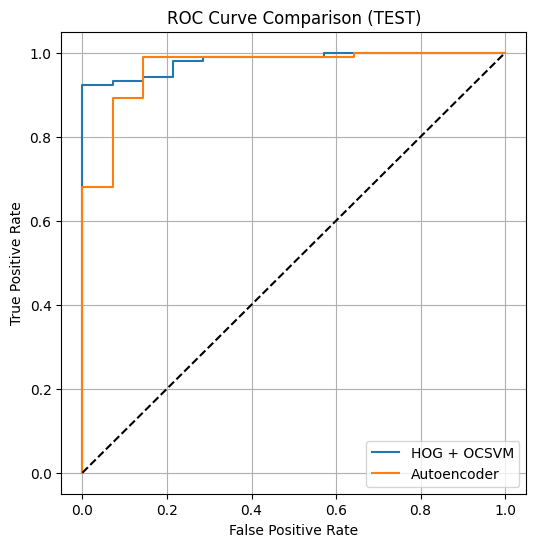

In [ ]:
# ------- ROC Curve -------
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr1, tpr1, _ = roc_curve(m1_ytrue, m1_scores)
fpr2, tpr2, _ = roc_curve(m2_ytrue, m2_scores)

plt.figure(figsize=(6,6))
plt.plot(fpr1, tpr1, label="HOG + OCSVM")
plt.plot(fpr2, tpr2, label="Autoencoder")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison (TEST)")
plt.legend()
plt.grid(True)
plt.show()


## 8.3 Precision recall curve comparing both methods on TEST

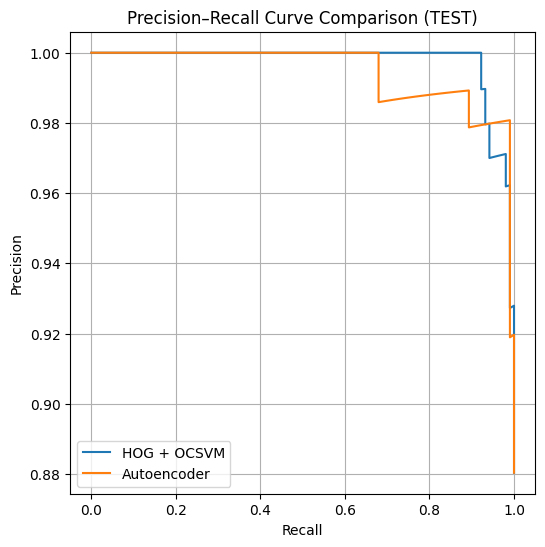

In [ ]:
# ------- Precision Recall Curve -------
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

p1, r1, _ = precision_recall_curve(m1_ytrue, m1_scores)
p2, r2, _ = precision_recall_curve(m2_ytrue, m2_scores)

plt.figure(figsize=(6,6))
plt.plot(r1, p1, label="HOG + OCSVM")
plt.plot(r2, p2, label="Autoencoder")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve Comparison (TEST)")
plt.legend()
plt.grid(True)
plt.show()


## 9. Conclusions

The results demonstrate that anomaly detection performance is strongly influenced by the nature of the defect. The HOG + OCSVM approach achieves higher overall performance, particularly for structural anomalies such as chipped pills, due to its ability to capture edge discontinuities through gradient-based features.

In contrast, the autoencoder shows reduced sensitivity to contamination-based anomalies such as dirt. This is likely because reconstruction-based models tend to smooth local irregularities, allowing small or texture-like defects to be reconstructed without significant error.

These findings highlight that model suitability depends not only on overall accuracy but also on the characteristics of the anomalies being detected. Handcrafted feature methods may be more effective for structured defects in small datasets, while deep learning approaches require careful design to avoid reconstructing anomalies.

Overall, the results emphasise the importance of aligning feature representation and model choice with the underlying properties of the anomaly detection task.

Future work could explore hybrid pipelines that combine structured feature extraction with learned representations to improve robustness across different anomaly types.